# **Calsificador de hongos**

En este modelo tiene como propósito generar un clasificador de diferetnes especies de hongos, para esto se todo un dataset de kaggle con multiples especies de hongos, este dataset es el siguiente:
- [Combined Kaggle Mushroom Images Dataset Example](https://www.kaggle.com/code/dariobaumberger/combined-kaggle-mushroom-images-dataset-example?select=images)

Este dataset tiene la siguiente información, tiene un total de 169 diferentes especies de hongos sin embargo tiene problemas de balances pues llegan a ser muchas fotos en algunos archivos y pocos en otros, por ello se promedio tomar tan solo 500 fotos de cada tipo de hongo que es un promedio y de esta froma se separo en 3 carpetas entre ellas dando las siguientes proporciones:
- train 70%
- validation 15%
- test 15%

Con esto se espera entrenar el modelo y no tener algun fallo, sin embargo si las métricas fallan se probar juntar los hongos por familia, generando menos tipos y más imagenes.

## **1. Cargar el Dataset**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se va hacia la carpeta donde se encuentra las imágenes para establecerse alli

In [6]:
%cd "/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Imagenes"
!pwd

/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Imagenes
/content/drive/MyDrive/Desarrollo de aplicaciones avanzadas de ciencias computacionales/Imagenes


Se verifica la información que se tiene

In [7]:
!ls

1-ETL.ipynb  Data


Se integra variables donde se indica las carpetas de training, validation y test

In [11]:
import os, shutil, random
from pathlib import Path
from PIL import Image

base_dir = 'Data'
train_dir = os.path.join(base_dir,'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

## **2. Separación del imágenes y transformación**

Se cargan las imágenes en diferentes variables de cada tipo.

Las imásgenes de training se hacen variaciones, tales como rotaciones, zoom, traslación, inclinación o voltearlas; de esta forma se genera artificaialmente más variaciones de las imágenes

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

conv_base = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

Found 47374 images belonging to 169 classes.
Found 10399 images belonging to 169 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Se observa ahora las formas de las imágenes y el total de estas, asi como las clases con las que van a contar

In [13]:
class_names = list(train_generator.class_indices.keys())

images, labels = train_generator.__next__()
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Total imágenes train:", train_generator.n)
print("Total clases:", train_generator.num_classes)
print("Clases:", class_names)

Images shape: (32, 224, 224, 3)
Labels shape: (32, 169)
Total imágenes train: 47374
Total clases: 169
Clases: ['Agaricus augustus', 'Agaricus xanthodermus', 'Amanita amerirubescens', 'Amanita augusta', 'Amanita brunnescens', 'Amanita calyptroderma', 'Amanita citrina', 'Amanita flavoconia', 'Amanita muscaria', 'Amanita pantherina', 'Amanita persicina', 'Amanita phalloides', 'Amanita rubescens', 'Amanita velosa', 'Apioperdon pyriforme', 'Armillaria borealis', 'Armillaria mellea', 'Armillaria tabescens', 'Artomyces pyxidatus', 'Bjerkandera adusta', 'Bolbitius titubans', 'Boletus edulis', 'Boletus pallidus', 'Boletus reticulatus', 'Boletus rex-veris', 'Calocera viscosa', 'Calycina citrina', 'Cantharellus californicus', 'Cantharellus cibarius', 'Cantharellus cinnabarinus', 'Cerioporus squamosus', 'Cetraria islandica', 'Chlorociboria aeruginascens', 'Chlorophyllum brunneum', 'Chlorophyllum molybdites', 'Chondrostereum purpureum', 'Cladonia fimbriata', 'Cladonia rangiferina', 'Cladonia stella

Se imprime una pequeña parte de las imágenes de cada especie para su verificación antes de pasar al entrenamiento

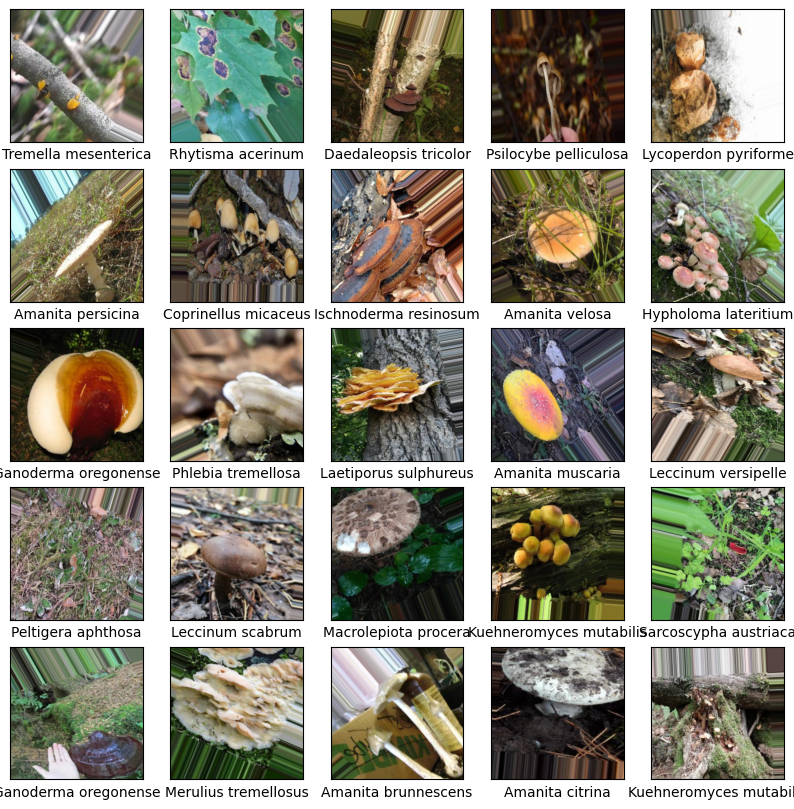

In [17]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = train_generator.__next__()
label_indices = np.argmax(labels, axis=1)

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])
    plt.xlabel(class_names[label_indices[i]])
plt.show()